# Analysis Notebook for isolating absorption scattering signal and comparing it to theory predictions

# We start by loading in the modules and data, and defining some of the key parameters

## First loading in modules

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import h5py
from radavg import RadialAverager
from decimal import Decimal
from scipy.interpolate import InterpolatedUnivariateSpline
import seaborn as sns
from decimal import Decimal
mpl.rcParams['mathtext.fontset'] = 'cm'

print('done')

done


## Loading in the data

In [2]:
f1 = 'Processed_Scattering_Data.h5'
hf1 = h5py.File(f1, 'r')
for item in hf1:
    print(item)
    exec('%s = np.array(hf1[item])' %str(item))

print(DG2_value.shape)
print(JF_Iq.shape)
print(fee_data.shape)
print(gas_pressure.shape)
print(pulsewidths.shape)
            
print('Processed Data Loaded In')

DG2_value
JF_Iq
fee_data
gas_pressure
pulsewidths
(1503783,)
(1503783, 40)
(1503783,)
(1503783,)
(1503783, 2)
Processed Data Loaded In


## Defining q bins and other experimental parameters.  Scattering detector related quantities are typically shaped either like the detector (8,512,1024), or they're q binned quantities shaped (40) for 40 q bins. The detector shape (8,512,1024) refers to 8 rectangular detector modules, each with 512x1024 pixels.  

In [3]:
mask = np.load('Detector_Mask.npy') #detector shaped array of zeros and ones, referring to 'bad pixels' and 'good pixels'
X = np.load('X_Coordinates.npy')
Y = np.load('Y_Coordinates.npy')
n_qbins = 40
x0, y0, Z = 1.25458071e+03, 4.67530896e+02, 8.20468586e+04 # Calibration parameters for the detector center and distance

distance = Z*1e-6
energy_keV = 9486.371113
wavelength = 12400./energy_keV #Angstrom
rr = np.sqrt((X+x0)**2 + (Y+y0)**2)*1e-6
theta = np.arctan2(rr, distance) / 2.0
q = 4*np.pi*np.sin(theta) / wavelength
ra = RadialAverager(q, mask=mask, n_bins=n_qbins)
phi_values = np.arctan2((Y+y0), (X+x0)) 
phi_values[phi_values < -1.*np.pi] += 2.*np.pi
polarization_correction = np.sin(phi_values)**2 + np.cos(phi_values)**2*np.cos(2*theta)**2
geometry_correction = np.cos(2*theta)**3
polarization_ra = ra(polarization_correction)
geometry_ra = ra(geometry_correction)
polarization_ra = polarization_ra[0:40]
geometry_ra = geometry_ra[0:40]
qbins = ra.bin_centers
bin_counts = ra.pixel_counts

fee_data = np.nan_to_num(fee_data)
fee_data /= 1000.
for i in range(0, qbins.size):
    JF_Iq[:,i] *= 1./fee_data

JF_Iq = np.nan_to_num(JF_Iq)

#Converting DG2 diode values into pulse energy values based on correlations between DG2 and Pulse Energy Detector ('Ebeam')
conversion_factor = 0.00015778594443152487
offset_value = 0.20774577461955623
mJ_value = DG2_value*conversion_factor + offset_value

print(polarization_correction.shape)
print(polarization_ra.shape)

C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:28: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:28: RuntimeWarning: invalid value encountered in multiply


(8, 512, 1024)
(40,)


# This next section concerns the treatment of the X-ray pulse

## Tau Calculation: How pulse structure data compares to 25fs Gaussian pulses

In [4]:
delta = np.nanmedian(pulsewidths[:,0])
print('From XTCAV data, the average pump probe delay is %.3f femtoseconds' %delta)
tau = delta*np.sqrt(np.pi)/2.
print('This corresponds to a tau value of %.3f femtoseconds' %tau)
print('A 25fs Gaussian pulse has a tau value of %.3f femtoseconds' %(25/(2*np.sqrt(2*np.log(2)))))
print('With Gaussian treatment, the XTCAV predicts pulses with a FWHM value of %.3f femtoseconds' %(tau*(2*np.sqrt(2*np.log(2)))))

From XTCAV data, the average pump probe delay is 12.595 femtoseconds
This corresponds to a tau value of 11.162 femtoseconds
A 25fs Gaussian pulse has a tau value of 10.617 femtoseconds
With Gaussian treatment, the XTCAV predicts pulses with a FWHM value of 26.284 femtoseconds


# This module depicts the spatial Gaussian treatment of the pulse.  The colormap shows the pulse fluence, and the dotted line shows the FWHM radius used to define the spot size.

2.278523875571947


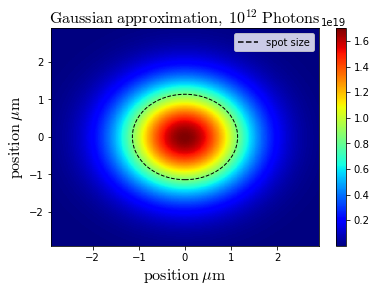

Fluence within 3 stdev integrates spatially to 9.946E+11 photons
Peak Fluence = 1.700E+19 photons/cm^2


In [5]:
from matplotlib.patches import Circle
def gauss(x, a, b, c): # p[0]==mean, p[1]==stdev
    return c/(b*np.sqrt(2*np.pi))*np.exp(-(x-a)**2/(2*b**2))

w_optimized_value = 0.9676 #microns
beam_radius = w_optimized_value*2*np.sqrt(2*np.log(2))
print(beam_radius)

Plotting_Values = np.arange(-3*beam_radius/(2*np.sqrt(2*np.log(2))), 3*beam_radius/(2*np.sqrt(2*np.log(2))), 0.01)
Plotting_Gaussian = np.outer(gauss(Plotting_Values, 0, beam_radius/(2*np.sqrt(2*np.log(2))), np.sqrt(1e12)*1e4), gauss(Plotting_Values, 0, beam_radius/(2*np.sqrt(2*np.log(2))), np.sqrt(1e12)*1e4))

Reimann_Width = ((Plotting_Values[1] - Plotting_Values[0])*1e-4)**2
Tot_Photons = np.sum(Reimann_Width*Plotting_Gaussian)
coordinates = np.reshape(np.concatenate((np.reshape(np.repeat(Plotting_Values, Plotting_Values.size), (Plotting_Values.size, Plotting_Values.size)), np.transpose(np.reshape(np.repeat(Plotting_Values, Plotting_Values.size), (Plotting_Values.size, Plotting_Values.size))))), (2, Plotting_Values.size, Plotting_Values.size))

plt.figure()
ax = plt.gca()
plt.pcolormesh(Plotting_Values, Plotting_Values, Plotting_Gaussian, cmap = 'jet')
plt.vlines( -(1/2.)*beam_radius, -0.01, 0.01, linestyle = '--', color = 'black', label = 'spot size')
circle = plt.Circle((0,0), radius = (1/2.)*beam_radius, label = 'spot size', linestyle = '--', color = 'black',  fill = False)
ax.add_artist(circle)
plt.xlabel('$\mathrm{position\;\mu m}$', fontsize = 16)
plt.ylabel('$\mathrm{position\;\mu m}$', fontsize = 16)
plt.title('$\mathrm{Gaussian\;approximation,\;10^{12}\;Photons}$', fontsize = 16)
plt.colorbar()
plt.legend()
plt.show()
#plt.savefig('Gaussian_Pulse.png', dpi = 150., bbox_inches = 'tight')


print('Fluence within 3 stdev integrates spatially to %.3E photons' %Decimal(Tot_Photons))
print('Peak Fluence = %.3E photons/cm^2' %Decimal(np.max(Plotting_Gaussian)))

## I'm collecting pulses which have at least 0.22 mJ of pulse energy, then obtaining the molecules/cm^3 shot by shot from the pressure readings

In [6]:
#Defining number of photons
Photon_Energy_mJ = fee_data*1.6022e-13 #A conversion from eV to mJ
good_indices = np.where(mJ_value > 0.22)[0]
print('%d pulses have at least 0.22 mJ of pulse energy' % good_indices.size)

DG2_good = DG2_value[good_indices]
NPhot_value = mJ_value[good_indices]/(Photon_Energy_mJ[good_indices]) #Number of photons in the pulse
Energy_value = mJ_value[good_indices]

#Defining Molecular Density
gas_pressure = np.array(gas_pressure, dtype = 'float')
P_array = gas_pressure - 0.62 #There's an offset of 0.62 torr in the pressure detector which must be accounted for
P_error = 0.22 #1 sigma in torr
Density_array = P_array*133.322/((1.380649e-23)*(298)*(1e6))
Density_error = P_error*133.322/((1.380649e-23)*(298)*(1e6))
l_cell = 0.24 #cm



1187965 pulses have at least 0.22 mJ of pulse energy


## Here I show the distribution of photon counts in the 1.19 million 'good pulses' 

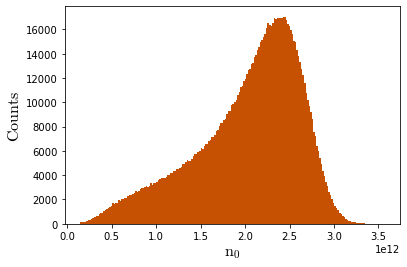

In [7]:
JF_Iq_Pulse_Subset = JF_Iq[good_indices,:]
Density_Median = np.nanmedian(Density_array[good_indices])
Density_Error = np.nanmedian(np.abs(Density_array[good_indices] - Density_Median))
Hist_NPhot, bins_NPhot = np.histogram(NPhot_value, bins = 200)
Hist_Energy, bins_Energy = np.histogram(Energy_value, bins = 200)
Reference_Values = bins_NPhot[0:200]
Reference_Values_Energy = bins_Energy[0:200]

plt.figure()
#plt.plot(bins_NPhot[0:199], Hist_NPhot[0:199])
plt.hist(NPhot_value, bins = 200, color = sns.xkcd_rgb["dark orange"])
#plt.plot(bins_Energy[0:199], Hist_Energy[0:199])
plt.xlabel('$\mathrm{n_0}$', fontsize = 16)
plt.ylabel('$\mathrm{Counts}$', fontsize = 16)
plt.show()
#plt.savefig('Phot_Paper_Histogram.png', dpi = 150., bbox_inches = 'tight')


## Average pump probe delay distribution in the 'good pulse' data set:

C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\numpy\lib\histograms.py:829: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\numpy\lib\histograms.py:830: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


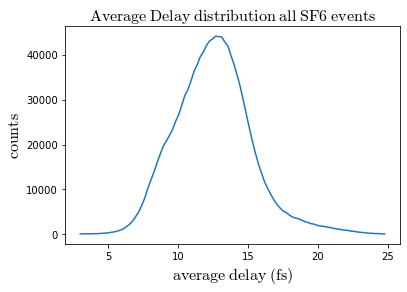

In [8]:
hist_time, bins_time = np.histogram(pulsewidths[:,0], range = (3,25), bins = 100)
plt.figure()
plt.plot(bins_time[0:hist_time.size], hist_time)
plt.title('$\mathrm{Average\;Delay\;distribution\;all\;SF6\;events}$', fontsize = 16)
plt.xlabel('$\mathrm{average\;delay\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{counts}$', fontsize = 16)
plt.show()

## And now combining the 2: this 2D histogram bins the pulses into average delay and photon count

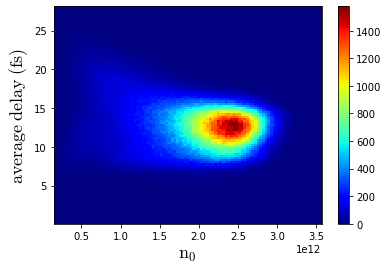

In [9]:
mJ_value = np.nan_to_num(mJ_value)
pulsewidths = np.nan_to_num(pulsewidths)
pulsewidths_good = pulsewidths[good_indices,0]

plt.figure()
plt.hist2d(NPhot_value[pulsewidths_good != 0], pulsewidths_good[pulsewidths_good != 0], bins = 100, cmap = 'jet')
plt.xlabel('$\mathrm{n_0}}$', fontsize = 18)
plt.ylabel('$\mathrm{average\;delay\;(fs)}$', fontsize = 18)
plt.colorbar()
plt.show()
#plt.savefig('pulsewidth_correlation.png', dpi = 150., bbox_inches = 'tight')

# This section covers the extraction of the absorption scattering signal from the data

## The data is first binned by Intensity.  A Gaussian function is fit to a subset of data with a given pulse energy range.  The peak position of the Gaussian is taken to be the intensity value, and the median absolute deviation is taken to be the error.  The final array is shaped (intensity_bins, q_bins)

In [10]:
import scipy.optimize as opt

def mad(arr):
    """ Median Absolute Deviation: a "Robust" version of standard deviation.
        Indices variabililty of the sample.
        https://en.wikipedia.org/wiki/Median_absolute_deviation
    """
    med = np.nanmedian(arr)
    return np.nanmedian(np.abs(arr - med))

p0 = [0,1,10.] # Inital guess is a normal distribution
errfunc = lambda p, x, y: gauss(x, p) - y # Distance to the target function

Binned_Distribution_Values = np.zeros((Reference_Values.size - 1, qbins.size))
Total_Errorbar_Values = np.zeros_like(Binned_Distribution_Values)
Counts_NoPulse_Array = np.zeros_like(Binned_Distribution_Values)
bounds = np.zeros(qbins.size)
bin_number = 50 
    
for h in range(0, qbins.size):
    for i in range(0, Reference_Values.size - 1):
        indices = np.where((NPhot_value >= Reference_Values[i])&(NPhot_value < Reference_Values[i+1]))[0] #with no pulse width restriction
        JF_Iq_subset = JF_Iq_Pulse_Subset[indices, h]
        MAD_sigma = mad(JF_Iq_subset)
        hist, bins = np.histogram(JF_Iq_subset, bins=bin_number)
        hist_max = np.max(hist)
        hist_where = np.where(hist == hist_max)[0]
        hist_where = np.int(np.average(hist_where))
        bins = bins[0:bin_number]
        bin_max = bins[hist_where]
        bins -= bin_max
        try: 
            p1, success = opt.curve_fit(gauss, bins, hist, ftol=1.49012e-10, xtol=1.49012e-10, gtol=1e-10)
 #           p1, success = opt.leastsq(errfunc, p0[:], args=(bins, hist))
            fit_mu, fit_stdev, Amp = p1
            FWHM = 2*np.sqrt(2*np.log(2))*fit_stdev
            if FWHM < 0: continue
            bin_range = np.max(bins) - np.min(bins)
            if fit_stdev > bin_range: continue
            Binned_Distribution_Values[i,h] = bin_max + p1[0]
            Total_Errorbar_Values[i,h] = MAD_sigma
            Counts_NoPulse_Array[i,h] = indices.size
        except Exception:
            fit_mu, fit_stdev, Amp = 0,0,0
            Binned_Distribution_Values[i,h] = 0
            Total_Errorbar_Values[i,h] = 0
            Counts_NoPulse_Array[i,h] = 0

Total_Errorbar_Values[Binned_Distribution_Values == 0] = np.nan
Binned_Distribution_Values[Binned_Distribution_Values == 0] = np.nan

print('Binned Array Created')

C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1112: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\optimize\minpack.py:829: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


Binned Array Created


## The fitting results with errorbars (in black) are compared to the distribution of measured scattering signal (in color)

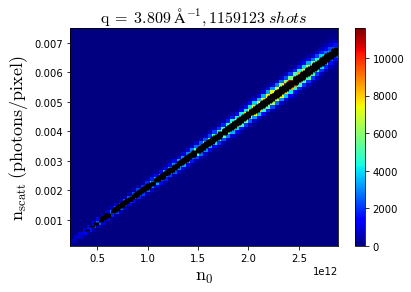

In [11]:
Min_Ref = 5
Max_Ref = 160
qbin_index = 34

indices = np.where((NPhot_value >= Reference_Values[Min_Ref])&(NPhot_value < Reference_Values[Max_Ref]))[0] #with no pulse width restriction
JF_Iq_subset = JF_Iq_Pulse_Subset[indices, qbin_index]

plt.figure()
plt.hist2d(NPhot_value[indices], JF_Iq_subset, bins = 60, cmap = 'jet')
plt.errorbar(Reference_Values[Min_Ref:Max_Ref], Binned_Distribution_Values[Min_Ref:Max_Ref, qbin_index], yerr = Total_Errorbar_Values[Min_Ref:Max_Ref, qbin_index], linewidth = 5, linestyle = '--', color = 'black')
plt.title('$\mathrm{q\;=\;%.3f\; \AA^{-1}}, %d\; shots$' % (qbins[qbin_index], indices.size), fontsize = 16)
plt.xlabel('$\mathrm{n_0}$', fontsize = 18)
plt.ylabel('$\mathrm{n_{scatt}\;(photons/pixel)}$', fontsize = 18)
plt.colorbar()
plt.show()

## X-ray polarization and effective pixel area corrections are made, and the quantities are converted into photons per steradian

In [12]:
A_pixel = (0.0075)**2 #Pixel area in cm
detector_distance = Z/10000. #Detector distance in cm
Binned_Distribution_Values *= (detector_distance)**2/A_pixel

for i in range(0, Reference_Values.size - 1):
    Binned_Distribution_Values[i,:] /= (polarization_ra*geometry_ra)

## A quadratic polynomial is fit to the scattering data, and a bootstrapping analysis is used to obtain the fitting coefficient values and error

In [13]:
from scipy.optimize import curve_fit 
from scipy.optimize import minimize

def quadratic(N, a, b, c):
    return  a + b*N + c*N**2

def error(x):
    return abs(np.nan_to_num((1/Error_qslice[q_slice > 0])*(q_slice[q_slice > 0]) - quadratic(Reference_Slice[q_slice > 0], x[0],x[1],x[2]))).sum()

def error_random(x):
    return abs(np.nan_to_num((1/sigma_err_total)*(randomdataY) - quadratic(Reference_Slice[q_slice > 0], x[0],x[1],x[2]))).sum()

method = 'SLSQP'
#method = 'Nelder-Mead'
MinDG2 = int(0.) #0.
HighDG2 = int(70.) #70.
STDEV_Values = Total_Errorbar_Values
SQRT_Counts = np.sqrt(Counts_NoPulse_Array)
Reference_Slice = Reference_Values[0:Reference_Values.size - 1]
Reference_Slice = Reference_Values[MinDG2:HighDG2]

a_matrix = np.zeros((qbins.size))
b_matrix = np.zeros((qbins.size))
c_matrix = np.zeros((qbins.size))
a_stdev_matrix = np.zeros((qbins.size))
b_stdev_matrix = np.zeros((qbins.size))
c_stdev_matrix = np.zeros((qbins.size))

for h in range(0, qbins.size):
    Error_qslice = np.nan_to_num(STDEV_Values[MinDG2:HighDG2,h]/SQRT_Counts[MinDG2:HighDG2,h])
    q_slice = Binned_Distribution_Values[MinDG2:HighDG2,h]
    q_slice = np.nan_to_num(q_slice)
    avg_error = mad(Error_qslice[MinDG2:HighDG2])
    Reference_Slice = np.nan_to_num(Reference_Slice)
    q_slice = np.nan_to_num(q_slice)
    fit_opt, fit_cov = curve_fit(quadratic, Reference_Slice[q_slice > 0], q_slice[q_slice > 0], sigma = Error_qslice[q_slice > 0], xtol = 1e-15, gtol = 1e-15)
    fit_err = np.sqrt(np.diag(fit_cov))
    a_start = fit_opt[0]
    b_start = fit_opt[1]
    c_start = fit_opt[2]
    bounds = (np.sort((-10*a_start, 10*a_start)), np.sort((-10*b_start, 10*b_start)), np.sort((-10*c_start, 10*c_start)))
    x0 = np.array((a_start, b_start, c_start))
    method = 'Nelder-Mead'
#    method = 'SLSQP'
    best_values = minimize(error, x0 = x0, method = method, bounds = bounds)
    output = best_values.x
    residuals = quadratic(Reference_Slice[q_slice > 0], a_start, b_start, c_start) - q_slice[q_slice > 0]
    sigma_res = np.std(residuals)
    sigma_err_total = np.sqrt(sigma_res**2 + Error_qslice[q_slice > 0]**2)
    a_random = []
    b_random = []
    c_random = []
    for i in range(0,200):
        randomDelta = np.random.normal(0., sigma_err_total, len(q_slice[q_slice > 0]))
        randomdataY = q_slice[q_slice > 0] + randomDelta
        fit_opt, fit_cov = curve_fit(quadratic, Reference_Slice[q_slice > 0], randomdataY, xtol = 1e-14, gtol = 1e-14)
        output_random = fit_opt
        a_random.append(output_random[0])
        b_random.append(output_random[1])
        c_random.append(output_random[2])
    a_random = np.array(a_random)
    b_random = np.array(b_random)
    c_random = np.array(c_random)
    a_matrix[h] = np.mean(a_random)
    b_matrix[h] = np.mean(b_random)
    c_matrix[h] = np.mean(c_random)
    a_stdev_matrix[h] = np.std(a_random)
    b_stdev_matrix[h] = np.std(b_random)
    c_stdev_matrix[h] = np.std(c_random)


print(randomDelta[0:30])       
print('fit array complete')


C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:534: RuntimeWarning: Method Nelder-Mead cannot handle constraints nor bounds.
  RuntimeWarning)


[ -30.0785046    19.32189821    0.71672037   83.79442403   15.14659915
   40.18867565 -120.91994651   38.03486303   -2.4297809    20.62971435
    8.60612409  -35.58352172   10.70465355   19.42986416  -27.98726087
   60.87395963   13.41849848   75.97182043   41.96397716  -29.4342957
   28.0551696   -54.59106336  -79.26583908   11.80111956   -6.72151239
   58.51544171   27.63815286  -15.84083217   97.66324522  -11.02977679]
fit array complete


## The linear scattering contribution is compared to theory scattering patterns

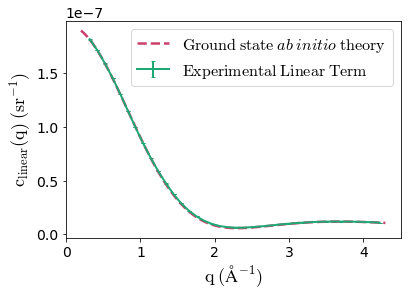

In [14]:
from scipy.io import loadmat
mpl.rcParams['mathtext.fontset'] = 'cm' #cm
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
Theory_Elastic = np.load('SF6_Debye_Total.npy')
Theory_Scale = 7.94e-26 #Thomson Cross Section
Match_Scale = 168. #Global scale to overlap theory with measurement
Theory_Ground = np.genfromtxt('sf6-gs-j0-total.dat')
Theory_Ground = np.array(Theory_Ground)
Theory_q = Theory_Ground[:,0] 
Theory_I = Theory_Ground[:,1]

plt.figure()
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 18)
(_, caps, _) = plt.errorbar(qbins[0:39], qbins[0:39]**0*b_matrix[0:39], yerr = 1*qbins[0:39]**0*b_stdev_matrix[0:39], label = '$\mathrm{Experimental\;Linear\;Term}$', linewidth = 2, capsize = 2, color = sns.xkcd_rgb["jade"])
for cap in caps:
    cap.set_color(sns.xkcd_rgb["jade"])
    cap.set_markeredgewidth(1)
plt.plot(Theory_q[10:215], Theory_q[10:215]**0*Theory_I[10:215]*Theory_Scale*Density_Median*l_cell/Match_Scale, label = '$\mathrm{Ground\;state\;}\it{ab\;initio}\;\mathrm{theory}$', linewidth = 2.5, linestyle = '--', color = sns.xkcd_rgb["dark pink"])
plt.ylabel('$\mathrm{c_{linear}(q)\;(sr^{-1})}$', fontsize = 18)
plt.legend(fontsize = "16")
plt.show()
#plt.savefig('bq_error_scaled.png', dpi = 150., bbox_inches='tight')


## The nonlinear fitting coefficient is plotted

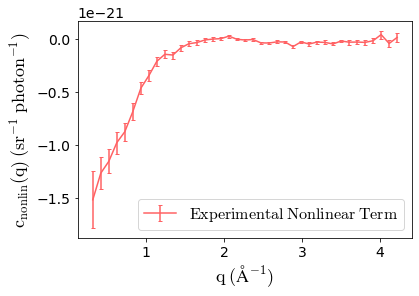

In [15]:
plt.figure()
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 18)
(_, caps, _) = plt.errorbar(qbins[0:39], c_matrix[0:39], yerr = c_stdev_matrix[0:39], capsize = 2, label = '$\mathrm{Experimental\;Nonlinear\;Term}$', color = sns.xkcd_rgb["coral pink"])
for cap in caps:
    cap.set_color(sns.xkcd_rgb["coral pink"])
    cap.set_markeredgewidth(1)
plt.ylabel('$\mathrm{c_{nonlin}(q)\;(sr^{-1}\;photon^{-1})}$', fontsize = 18)
plt.legend(fontsize = 16, loc = 'lower right')
plt.show()
#plt.savefig('cq.png', dpi = 150., bbox_inches='tight')


## Delta N from SI section S2.2 is calculated here

[-1.29923692e+11]
The photon offset is -1.299E+11 photons
The mJ offset is -1.566E-01 mJ
The DG2 offset is -9.923E+02 DG2 units


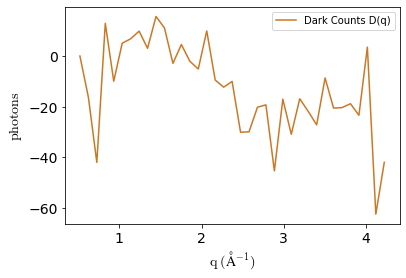

In [16]:
qmin = int(2.)
qmax = int(39.)
def dI_error(d):
    return np.sum(abs(a_matrix[qmin:qmax] - (b_matrix[qmin:qmax]*d - c_matrix[qmin:qmax]*d**2)))

#method = 'SLSQP'
method = 'Nelder-Mead'
x0 = (np.nanmean(a_matrix[qmin:qmax]/b_matrix[qmin:qmax]))
best_values = minimize(dI_error, x0 = x0, method = method)
output = best_values.x
print(output)
dn = output[0]
B_q = a_matrix - b_matrix*dn + c_matrix*dn**2
print('The photon offset is %.3E photons' % Decimal(dn))
dE = dn*np.nanmean(Photon_Energy_mJ)
print('The mJ offset is %.3E mJ' % Decimal(dE))
d_DG2 = dE/conversion_factor
print('The DG2 offset is %.3E DG2 units' % Decimal(d_DG2))

plt.figure()
plt.plot(qbins[qmin:qmax], B_q[qmin:qmax], label = 'Dark Counts D(q)', color = sns.xkcd_rgb["brownish orange"])
plt.legend()
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 14)
plt.ylabel('$\mathrm{photons}$', fontsize = 14)
plt.show()
#plt.savefig('Bq_fit.png', dpi = 150., bbox_inches = 'tight')

## We next visualize the scattering signal with the linear contribution removed

## First the data prior to pulse energy binning

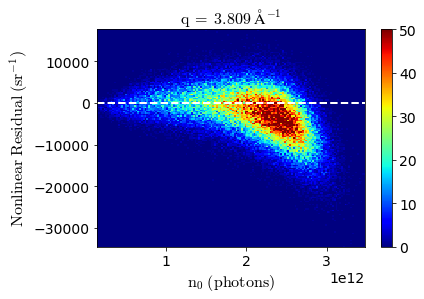

In [17]:
w_intensity = 9.676e-5
t_intensity = 25*1e-15
qbin_value = 3
Intensity_values = Energy_value[0:100000]/(1000.*np.pi*w_intensity**2*t_intensity) #Square Top Calculation
N_0 = 1.299E+11 
plt.figure()
plt.xlabel('$\mathrm{n_0\;(photons)}$', fontsize = 16)
plt.ylabel('$\mathrm{Nonlinear\;Residual\;(sr^{-1})}$', fontsize = 16)
plt.title('$\mathrm{q\;=\;%.3f\; \AA^{-1}}$' % (qbins[qbin_index]), fontsize = 16)
plt.hlines(0, np.min(NPhot_value), np.max(NPhot_value), linestyle = '--', linewidth = 2, color = 'white')
plt.hist2d(NPhot_value[0:100000], JF_Iq_Pulse_Subset[0:100000,qbin_value]/(polarization_ra[qbin_value]*geometry_ra[qbin_value])*(detector_distance)**2/A_pixel - b_matrix[qbin_value]*(NPhot_value[0:100000]) - a_matrix[qbin_value], bins = 150, cmap = 'jet') #Fluence
plt.colorbar()

plt.clim(0,50)
plt.show()
#plt.savefig('Nonlinearity_Figure_Paper_Inset.png', dpi = 150., bbox_inches='tight')

## And now the pulse energy binned data, with the quadratic contribution fitted

C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in greater
C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in greater


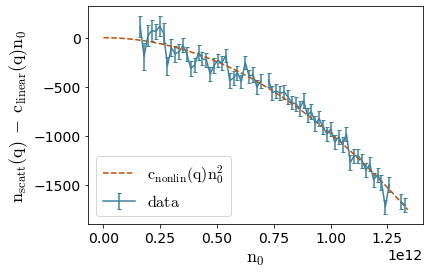

In [18]:
Linear_Subtracted_Binned_Data = np.zeros_like(Binned_Distribution_Values)
Linear_Subtracted_Data_Error = np.zeros_like(Binned_Distribution_Values)

for i in range(0, qbins.size):
    q_slice = Binned_Distribution_Values[:,i]
    q_corrected = q_slice - b_matrix[i]*Reference_Values[0:Reference_Values.size -1] 
    total_error = STDEV_Values[:,i]/SQRT_Counts[:,i]
    Linear_Subtracted_Binned_Data[:,i] = q_corrected
    Linear_Subtracted_Data_Error[:,i] = total_error


min_DG2 = int(0.)
max_DG2 = int(70.)
qbin_value = 3
bin_start = np.mean((qbins[qbin_value - 1], qbins[qbin_value]))
bin_end = np.mean((qbins[qbin_value], qbins[qbin_value + 1]))
i = qbin_value
Extrapolated_Reference_Values = np.arange(0, Reference_Values[max_DG2], 0.05e11)
total_error = Linear_Subtracted_Data_Error[min_DG2:max_DG2,i]*((detector_distance)**2/A_pixel)
Error_Sorted = sorted(total_error)
avg_error = np.nanmean(Error_Sorted[0:70])
q_corrected = Linear_Subtracted_Binned_Data[min_DG2:max_DG2,i] - a_matrix[i]
q_corrected[total_error > 2*avg_error] = np.nan
total_error[total_error > 2*avg_error] = np.nan
plt.figure()
plt.xlabel('$\mathrm{n_0}$', fontsize = 18)
plt.ylabel('$\mathrm{n_{scatt}(q)\;-\;c_{linear}(q)n_0}$', fontsize = 18)
(_, caps, _) = plt.errorbar(Reference_Values[min_DG2:max_DG2], q_corrected, yerr = 2*total_error, label = '$\mathrm{data}$', capsize = 2, color = sns.xkcd_rgb["dirty blue"])
for cap in caps:
    cap.set_color(sns.xkcd_rgb["dirty blue"])
    cap.set_markeredgewidth(1)
plt.plot(Extrapolated_Reference_Values, c_matrix[i]*(Extrapolated_Reference_Values)**2, label = '$\mathrm{c_{nonlin}(q)n_0^2}$', linestyle = '--', color = sns.xkcd_rgb["burnt orange"])
plt.legend(loc = 'lower left', fontsize = "16")
    #plt.xlim(0,2)
plt.show()
#plt.savefig('match_LV04_Frame_%d.png' % i, dpi = 150., bbox_inches='tight')

## A bootstrapping analysis was performed in a seperate script to obtain the optimized w value (spatial focusing parameter).  This module plots and determines the result, and performs some of the set up for higher order contributions to the data. 

The optimized w value is 9.676E-05 +- 1.380E-06 cm^2
w relative error is 1.426 percent


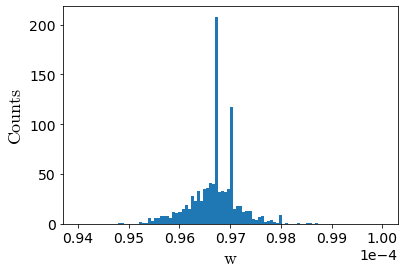

In [19]:
from scipy.special import erf 
tau_test = 10.616522503600239
absorption_theory_sigma = 4.789e-21

r_grid = np.arange(0, 6e-4, 6e-4/250.)
r_space = r_grid[1] - r_grid[0]
t_grid = np.arange(-40, 40, 80/50.)
t_space = t_grid[1] - t_grid[0]

def phi_peak(w, photon_number):
    return (2*photon_number/(np.pi*w**2*np.sqrt(np.pi)*tau_test))

def Fluence(w, photon_number):
    return phi_peak(w, photon_number)*np.sqrt(np.pi)*tau_test*np.exp(-2*r_grid**2/w**2)

Ion_Perdiff = np.genfromtxt('sf6-simulated.dat')
Ion_Perdiff = np.array(Ion_Perdiff)
Theory1q = Ion_Perdiff[:,0]
Theory_Perdiff = Ion_Perdiff[:,1]/100.

Theory_Ion = Theory_I*(Theory_Perdiff + 1)

Theory_Ground_Spline = InterpolatedUnivariateSpline(Theory_q[25:210], Theory_I[25:210])
Theory_Ion_Spline = InterpolatedUnivariateSpline(Theory_q[25:210], Theory_Ion[25:210])

Theory_Ground_Pattern =  Theory_Ground_Spline(qbins)*Theory_Scale*(detector_distance**2/A_pixel)/Match_Scale
Theory_Ion_Pattern =  Theory_Ion_Spline(qbins)*Theory_Scale*(detector_distance**2/A_pixel)/Match_Scale

w_values = np.load('w_random_theory.npy')
w_indices = np.where((w_values >= 0.9e-4) & (w_values <= 1.2e-4))[0]
w_subset = w_values[w_indices]
w_opt = np.mean(w_subset)
w_error = np.std(w_subset)
print('The optimized w value is %.3E +- %.3E cm^2' % (Decimal(w_opt), Decimal(w_error)))
print('w relative error is %.3f percent' % Decimal(100*w_error/w_opt))


plt.figure()
plt.hist(w_values, bins = 100, range = (0.94e-4, 1.0e-4))
plt.xlabel('$\mathrm{w}$', fontsize = 18)
plt.ylabel('$\mathrm{Counts}$', fontsize = 18)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.show()


## The modified scattering formula S21 in the SI is fit to the data over an extended pulse energy range.  The quadratic fitting fails past a certain pulse energy, due to too many ground state molecules being depleted.  The agreement of the ground state depletion modified formula with the data indicates that the w value determined in the previous module is good.  

C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in greater
C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:36: RuntimeWarning: invalid value encountered in greater
C:\Users\natha\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:37: RuntimeWarning: invalid value encountered in greater


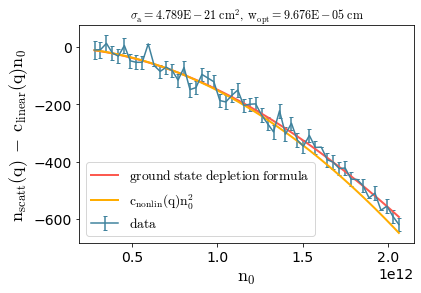

In [20]:
start_plot_index = 0
end_plot_index = 130
start_plot_index_c = 20
end_plot_index_c = 68
qbin_value = int(10)

def n_scatt_theory_Theory(w_value, photon_number, nonlinearity_scale):
    return Theory_Ion_Pattern*Density_Median*l_cell*photon_number + 2*np.pi*Density_Median*l_cell*(Theory_Ground_Pattern - Theory_Ion_Pattern)*phi_peak(w_value, photon_number)*np.sum(r_grid*np.exp(-2*r_grid**2/w_value**2)*r_space*np.sum(t_space*np.exp(np.outer((-1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number), (erf(t_grid/(tau_test)))))*np.transpose(np.reshape(np.repeat(np.exp(-1*t_grid**2/(tau_test)**2), r_grid.size), (t_grid.size, r_grid.size)))/(np.reshape(np.repeat(np.exp((1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number)), t_grid.size), (r_grid.size, t_grid.size)) + nonlinearity_scale*absorption_theory_sigma*Density_Median*l_cell*(np.reshape(np.repeat(np.exp((1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number)), t_grid.size), (r_grid.size, t_grid.size)) - np.exp(np.outer((-1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number), (erf(t_grid/tau_test)))))), axis = 1))

def n_scatt_array_mol_function_Theory(w_value):
    n_scatt_array_mol = np.zeros((qbins.size, Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c].size))
    for i in range(0, int(end_plot_index_c - start_plot_index_c)):
        photon_count = Extrapolated_Reference_Values[i+start_plot_index_c]
        n_scatt_array_mol[:,i] = (A_pixel/detector_distance**2)*(n_scatt_theory_Theory(w_value, photon_count, 0) - Theory_Ground_Pattern*Density_Median*l_cell*photon_count)
    return n_scatt_array_mol

min_DG2 = int(0)
max_DG2 = int(170)
total_error = Linear_Subtracted_Data_Error[min_DG2:max_DG2,qbin_value]
Error_Sorted = sorted(total_error)
avg_error = np.nanmean(Error_Sorted[0:70])
total_error[total_error > 2*avg_error] = np.nan
Extrapolated_Reference_Values = np.arange(0, 1*Reference_Values[max_DG2], 1*0.35e11)
q_corrected = Linear_Subtracted_Binned_Data[min_DG2:max_DG2,qbin_value] - a_matrix[qbin_value]
q_corrected = np.nan_to_num(q_corrected)
q_subset = q_corrected[start_plot_index:end_plot_index]
Ref_Subset = Reference_Values[start_plot_index:end_plot_index]
exp_data_spline = InterpolatedUnivariateSpline(Ref_Subset[q_subset != 0], q_subset[q_subset != 0])
exp_data = exp_data_spline(Extrapolated_Reference_Values)
randomdataY = exp_data
start_plot_index_c = 8
end_plot_index_c = 60
qbin_value = 10
i = qbin_value
q_corrected = Linear_Subtracted_Binned_Data[min_DG2:max_DG2,qbin_value] - a_matrix[qbin_value]
q_corrected[total_error > 2*avg_error] = np.nan
total_error[total_error > 2*avg_error] = np.nan
q_corrected = np.nan_to_num(q_corrected)
q_subset = q_corrected[start_plot_index:end_plot_index]
Ref_Subset = Reference_Values[start_plot_index:end_plot_index]
exp_data_spline = InterpolatedUnivariateSpline(Ref_Subset[q_subset != 0], q_subset[q_subset != 0])
exp_data = exp_data_spline(Extrapolated_Reference_Values)
err_total = 2*total_error[start_plot_index_c:end_plot_index_c]/(A_pixel/detector_distance**2)
err_total = np.nan_to_num(err_total)

def n_scatt_theory_Theory(w_value, photon_number, nonlinearity_scale):
    return Theory_Ion_Pattern*Density_Median*l_cell*photon_number + 2*np.pi*Density_Median*l_cell*(Theory_Ground_Pattern - Theory_Ion_Pattern)*phi_peak(w_value, photon_number)*np.sum(r_grid*np.exp(-2*r_grid**2/w_value**2)*r_space*np.sum(t_space*np.exp(np.outer((-1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number), (erf(t_grid/(tau_test)))))*np.transpose(np.reshape(np.repeat(np.exp(-1*t_grid**2/(tau_test)**2), r_grid.size), (t_grid.size, r_grid.size)))/(np.reshape(np.repeat(np.exp((1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number)), t_grid.size), (r_grid.size, t_grid.size)) + nonlinearity_scale*absorption_theory_sigma*Density_Median*l_cell*(np.reshape(np.repeat(np.exp((1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number)), t_grid.size), (r_grid.size, t_grid.size)) - np.exp(np.outer((-1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number), (erf(t_grid/tau_test)))))), axis = 1))

def n_scatt_array_mol_function_Theory(w_value):
    n_scatt_array_mol = np.zeros((qbins.size, Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c].size))
    for i in range(0, int(end_plot_index_c - start_plot_index_c)):
        photon_count = Extrapolated_Reference_Values[i+start_plot_index_c]
        n_scatt_array_mol[:,i] = (A_pixel/detector_distance**2)*(n_scatt_theory_Theory(w_value, photon_count, 0) - Theory_Ground_Pattern*Density_Median*l_cell*photon_count)
    return n_scatt_array_mol
w_test = w_opt

plt.figure()
(_, caps, _) = plt.errorbar(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], exp_data[start_plot_index_c:end_plot_index_c], yerr = err_total, label = '$\mathrm{data}$', color = sns.xkcd_rgb["dirty blue"], capsize = 2)
for cap in caps:
    cap.set_color(sns.xkcd_rgb["dirty blue"])
    cap.set_markeredgewidth(1)
plt.plot(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], n_scatt_array_mol_function_Theory(w_test)[qbin_value, :], color = sns.xkcd_rgb["coral"], linewidth = 2.0, label = '$\mathrm{ground\;state\;depletion\;formula}$')
plt.plot(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], c_matrix[qbin_value]*Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c]**2, color = sns.xkcd_rgb["orange yellow"], linewidth = 2.0, label = '$\mathrm{c_{nonlin}(q)n_0^2}$')
plt.xlabel('$\mathrm{n_0}$', fontsize = 18)
plt.ylabel('$\mathrm{n_{scatt}(q)\;-\;c_{linear}(q)n_0}$', fontsize = 18)
plt.legend(fontsize = 13.5)
plt.title('$\mathrm{\sigma_a = %.3E\;cm^2,\;w_{opt}=%.3E\;cm}$' % (Decimal(absorption_theory_sigma), Decimal(w_opt)))
plt.show()
#plt.savefig('w_opt_theory_figure.png', dpi = 150., bbox_inches = 'tight')

## Higher order truncations of formula S21 are fit to the data.  The plot shows that while quadratic fitting fails past a certain pulse energy, cubic fitting can sufficiently describe the data with ground state depletion.  If the quartic fit is un-commented, one can see that by eye, it's indistinguishable from the full expression within this pulse energy range.

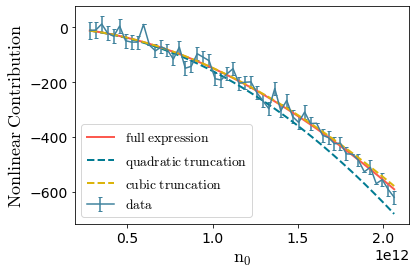

In [21]:
Theory_Ground_Pattern =  Theory_I[25:210]*Theory_Scale/Match_Scale
Theory_Ion_Pattern =  Theory_Ion[25:210]*Theory_Scale/Match_Scale
q_size = int(210 - 25)
tau = 25/(2*np.sqrt(2*np.log(2)))
r_grid = np.arange(0, 4*w_test, 4*w_test/250.)
r_space = r_grid[1] - r_grid[0]
t_grid = np.arange(-40, 40, 80/50.)
t_space = t_grid[1] - t_grid[0]

def n_scatt_theory_true(w_value, photon_number):
    return Theory_Ion_Pattern*Density_Median*l_cell*photon_number + 2*np.pi*Density_Median*l_cell*(Theory_Ground_Pattern - Theory_Ion_Pattern)*phi_peak(w_value, photon_number)*np.sum(r_grid*np.exp(-2*r_grid**2/w_value**2)*r_space*np.sum(t_space*np.exp(np.outer((-1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number), (erf(t_grid/(tau)))))*np.transpose(np.reshape(np.repeat(np.exp(-1*t_grid**2/(tau)**2), r_grid.size), (t_grid.size, r_grid.size)))/(np.reshape(np.repeat(np.exp((1/2.)*absorption_theory_sigma*Fluence(w_value, photon_number)), t_grid.size), (r_grid.size, t_grid.size))), axis = 1))

def n_scatt_theory_quadratic_truncation(w_value, photon_number):
    return Theory_Ground_Pattern*Density_Median*l_cell*photon_number + (Theory_Ion_Pattern - Theory_Ground_Pattern)*Density_Median*l_cell*((absorption_theory_sigma*photon_number**2)/(2*np.pi*w_value**2))

def n_scatt_theory_cubic_truncation(w_value, photon_number):
    return Theory_Ground_Pattern*Density_Median*l_cell*photon_number + (Theory_Ion_Pattern - Theory_Ground_Pattern)*Density_Median*l_cell*((absorption_theory_sigma*photon_number**2)/(2*np.pi*w_value**2) - (2*absorption_theory_sigma**2*photon_number**3)/(9*np.pi**2*w_value**4))

def n_scatt_theory_quartic_truncation(w_value, photon_number):
    return Theory_Ground_Pattern*Density_Median*l_cell*photon_number + (Theory_Ion_Pattern - Theory_Ground_Pattern)*Density_Median*l_cell*((absorption_theory_sigma*photon_number**2)/(2*np.pi*w_value**2) - (2*absorption_theory_sigma**2*photon_number**3)/(9*np.pi**2*w_value**4) + (absorption_theory_sigma**3*photon_number**4)/(12*np.pi**3*w_value**6))

def n_scatt_plotting_function_true(w_value):
    n_scatt_array_mol = np.zeros((q_size, Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c].size))
    for i in range(0, int(end_plot_index_c - start_plot_index_c)):
        photon_count = Extrapolated_Reference_Values[i+start_plot_index_c]
        n_scatt_array_mol[:,i] = (n_scatt_theory_true(w_value, photon_count) - Theory_Ground_Pattern*Density_Median*l_cell*photon_count)
    return n_scatt_array_mol

def n_scatt_plotting_function_quadratic_truncation(w_value):
    n_scatt_array_mol = np.zeros((q_size, Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c].size))
    for i in range(0, int(end_plot_index_c - start_plot_index_c)):
        photon_count = Extrapolated_Reference_Values[i+start_plot_index_c]
        n_scatt_array_mol[:,i] =(n_scatt_theory_quadratic_truncation(w_value, photon_count) - Theory_Ground_Pattern*Density_Median*l_cell*photon_count)
    return n_scatt_array_mol

def n_scatt_plotting_function_cubic_truncation(w_value):
    n_scatt_array_mol = np.zeros((q_size, Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c].size))
    for i in range(0, int(end_plot_index_c - start_plot_index_c)):
        photon_count = Extrapolated_Reference_Values[i+start_plot_index_c]
        n_scatt_array_mol[:,i] =(n_scatt_theory_cubic_truncation(w_value, photon_count) - Theory_Ground_Pattern*Density_Median*l_cell*photon_count)
    return n_scatt_array_mol

def n_scatt_plotting_function_quartic_truncation(w_value):
    n_scatt_array_mol = np.zeros((q_size, Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c].size))
    for i in range(0, int(end_plot_index_c - start_plot_index_c)):
        photon_count = Extrapolated_Reference_Values[i+start_plot_index_c]
        n_scatt_array_mol[:,i] =(n_scatt_theory_quartic_truncation(w_value, photon_count) - Theory_Ground_Pattern*Density_Median*l_cell*photon_count)
    return n_scatt_array_mol

qbin_value_poly = np.digitize(qbins[qbin_value], Theory1q)

plt.figure()
(_, caps, _) = plt.errorbar(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], exp_data[start_plot_index_c:end_plot_index_c], yerr = err_total, label = '$\mathrm{data}$', color = sns.xkcd_rgb["dirty blue"], capsize = 2)
for cap in caps:
    cap.set_color(sns.xkcd_rgb["dirty blue"])
    cap.set_markeredgewidth(1)
plt.plot(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], n_scatt_plotting_function_true(w_test)[qbin_value_poly - 25, :], color = sns.xkcd_rgb["coral"], linewidth = 2.0, label = '$\mathrm{full\;expression}$')
plt.plot(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], n_scatt_plotting_function_quadratic_truncation(w_test)[qbin_value_poly - 25,:], linestyle = '--', color = sns.xkcd_rgb["ocean"], linewidth = 2.0, label = '$\mathrm{quadratic\;truncation}$')
plt.plot(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], n_scatt_plotting_function_cubic_truncation(w_test)[qbin_value_poly - 25,:], linestyle = '--', color = sns.xkcd_rgb["gold"], linewidth = 2.0, label = '$\mathrm{cubic\;truncation}$')
#plt.plot(Extrapolated_Reference_Values[start_plot_index_c:end_plot_index_c], n_scatt_plotting_function_quartic_truncation(w_test)[qbin_value_poly - 25,:], linestyle = '--', color = sns.xkcd_rgb["jade"], linewidth = 2.0, label = '$\mathrm{quartic\;truncation}$')
plt.xlabel('$\mathrm{n_0}$', fontsize = 18)
plt.ylabel('$\mathrm{Nonlinear\;Contribution}$', fontsize = 18)
plt.legend(fontsize = 13.5)
plt.show()
#plt.savefig('w_opt_theory_figure.png', dpi = 150., bbox_inches = 'tight')


## Figure 4a from the main manuscript is produced, by taking the ratio of nonlinear to linear fitting coefficients.

8.140915544449236e-14
1.064990780540834


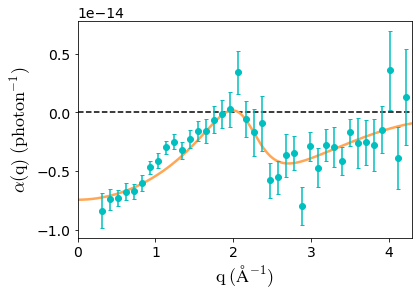

The global fitting scale and predicted scale are off by 6.499 percent


In [22]:
from scipy.io import loadmat

w_opt = 9.676e-5
qmin = int(0.)
qmax = int(39.)
q_CAS_max = int(215.)

numerator = c_matrix[qmin:qmax]
denominator = ((b_matrix[qmin:qmax]) - 2*dn*c_matrix[qmin:qmax])
error_numerator = c_stdev_matrix[qmin:qmax]
error_denominator = np.sqrt(b_stdev_matrix[qmin:qmax]**2 + (2*dn*c_stdev_matrix[qmin:qmax])**2)
error_total = abs(numerator/denominator)*np.sqrt((error_numerator/numerator)**2 + (error_denominator/denominator)**2)
qbin_subset = qbins[qmin:qmax]
w_new = w_opt
C = 4.789e-21/(2*np.pi*w_new**2)
print(C)
Global_Fit_Scale = 0.867
Predicted_Scale = C*1e13
Comparison_Factor = Global_Fit_Scale/Predicted_Scale
print(Comparison_Factor)
scale_percent_difference = 100*(Comparison_Factor - 1.00)


plt.figure()
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 18)
plt.ylabel(r'$\mathrm{\alpha(q)\;(photon^{-1})}$', fontsize = 18)
plt.hlines(0, 0, qbins[qmax], color = 'black', linestyle = '--')
plt.plot(Theory1q[0:q_CAS_max], Comparison_Factor*C*Theory_Perdiff[0:q_CAS_max], linewidth = 2.5, color = sns.xkcd_rgb["pale orange"], label = '$\mathrm{Theory\;Scale}$')
(_, caps, _) = plt.errorbar(qbin_subset, numerator/denominator, yerr = error_total, fmt = 'co', zorder = 5, label = '$\mathrm{Experiment}$', alpha = 1.0, capsize = 2)
for cap in caps:
    cap.set_color('c')
    cap.set_markeredgewidth(1)
plt.xlim(0,4.3)
#plt.legend()
plt.show()
#plt.savefig('Figure_4_Scale_Comparison.png', dpi = 150., bbox_inches='tight')

print('The global fitting scale and predicted scale are off by %.3f percent' % scale_percent_difference)

# This final section plots the theory results

## We start by showing the calculation for the most probable decay channel.  We calculate the time dependence of the electronic states, then we plot alpha(q, t); a time dependent prediction of the plot in the previous module.  

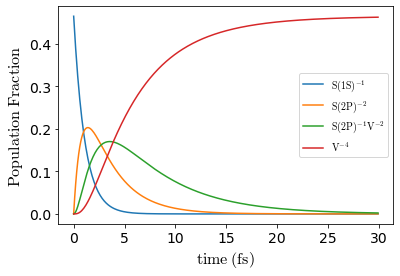

In [23]:
Global_Weight = 0.4644432400146234
life_1 = 1.1
life_2 = 2.8
life_3 = 5.6

time_steps = np.arange(0, 30, 0.1)
Pop_1 = Global_Weight*np.exp(-1*time_steps/life_1)
Pop_2 = Global_Weight*np.exp(-1*time_steps/life_2)*(1 - np.exp(-1*time_steps/life_1))
Pop_3 = Global_Weight*np.exp(-1*time_steps/life_3)*(1 - np.exp(-1*time_steps/life_1))*(1 - np.exp(-1*time_steps/life_2))
Pop_4 =  Global_Weight*(1 - np.exp(-1*time_steps/life_1))*(1 - np.exp(-1*time_steps/life_2))*(1 - np.exp(-1*time_steps/life_3))

plt.figure()
plt.plot(time_steps, Pop_1, label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(time_steps, Pop_2, label = '$\mathrm{S(2P)^{-2}}$')
plt.plot(time_steps, Pop_3, label = '$\mathrm{S(2P)^{-1}V^{-2}}$')
plt.plot(time_steps, Pop_4, label = '$\mathrm{V^{-4}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.legend()
plt.show()

Population_Array = np.zeros((4, time_steps.size))
Population_Array[0,:] = Pop_1
Population_Array[1,:] = Pop_2
Population_Array[2,:] = Pop_3
Population_Array[3,:] = Pop_4

## Next Making the Contour Plot

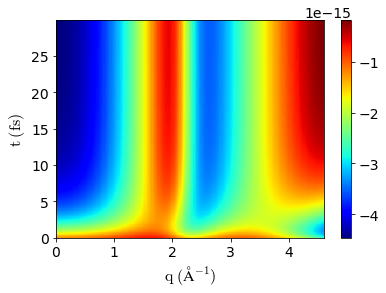

In [24]:
au2ang = 0.52918

Scatt_Ground = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-j0-total.dat')
Scatt_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s1-1s-j0-total.dat')
Scatt_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s2-2p-2p-d-j0-total.dat')
Scatt_3 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s3-4t1u-1-j0-total.dat')
Scatt_4 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s4-4t1u-1-j0-total.dat')
Scatt_GroundI = Scatt_Ground[:,1] + 70.
Scatt_1I = Scatt_1[:,1] + 69.
Scatt_2I = Scatt_2[:,1] + 68.
Scatt_3I = Scatt_3[:,1] + 67.
Scatt_4I = Scatt_4[:,1] + 66.

Scatt_q = Scatt_Ground[:,0]/au2ang
PerDiff1 = (Scatt_1I - Scatt_GroundI)/Scatt_GroundI
PerDiff2 = (Scatt_2I - Scatt_GroundI)/Scatt_GroundI
PerDiff3 = (Scatt_3I - Scatt_GroundI)/Scatt_GroundI
PerDiff4 = (Scatt_4I - Scatt_GroundI)/Scatt_GroundI

contour_array = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array[i,:] = Population_Array[0,i]*PerDiff1 + Population_Array[1,i]*PerDiff2 + Population_Array[2,i]*PerDiff3 + Population_Array[3,i]*PerDiff4
    
qhigh = 230
plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('contour_test.png', dpi = 150., bbox_inches = 'tight')

## We now make equivalent plots for all 6 channels.  Sulfur decays are labelled with 1, 2, 3, while Fluorine decays are labelled with 4, 5, 6.

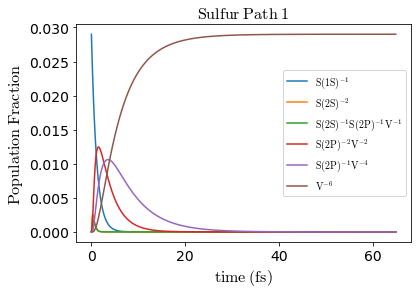

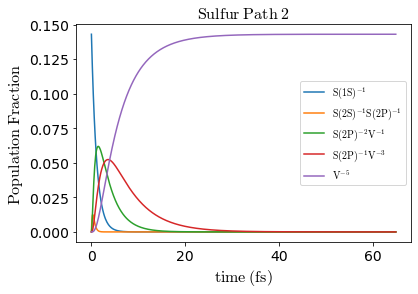

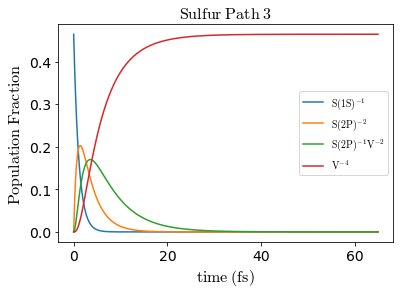

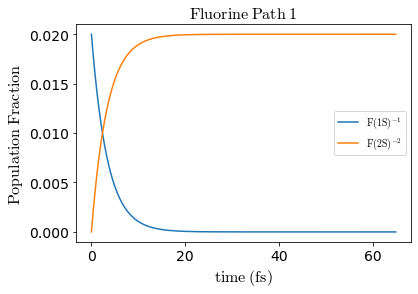

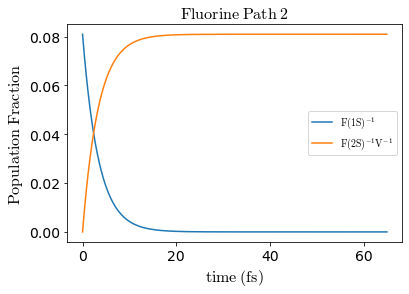

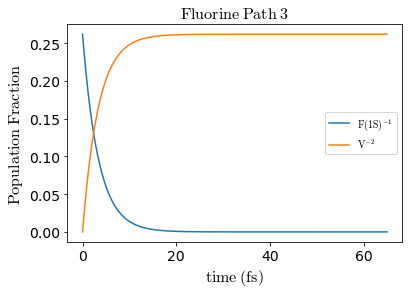

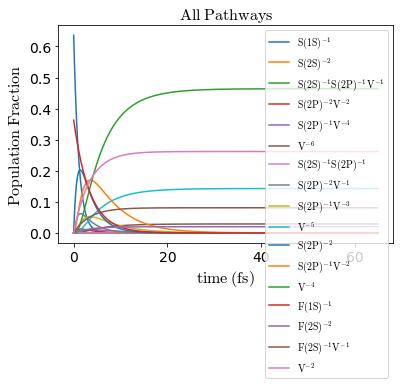

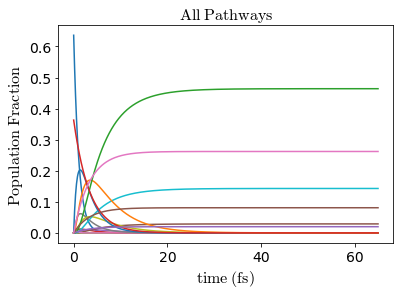

In [25]:
Global_Weight_1 = 0.029
Global_Weight_2 = 0.143
Global_Weight_3 = 0.464
Global_Weight_4 = 0.02
Global_Weight_5 = 0.081
Global_Weight_6 = 0.262

life_1_1 = 1.1
life_1_2 = 0.3
life_1_3 = 0.3
life_1_4 = 2.8
life_1_5 = 5.6
life_2_1 = 1.1
life_2_2 = 0.3
life_2_3 = 2.8
life_2_4 = 5.6
life_3_1 = 1.1
life_3_2 = 2.8
life_3_3 = 5.6
life_4_1 = 3.4
life_5_1 = 3.4
life_6_1 = 3.4

time_steps = np.arange(0, 65, 0.1)
Pop_1_1 = Global_Weight_1*np.exp(-1*time_steps/life_1_1)
Pop_1_2 = Global_Weight_1*np.exp(-1*time_steps/life_1_2)*(1 - np.exp(-1*time_steps/life_1_1))
Pop_1_3 = Global_Weight_1*np.exp(-1*time_steps/life_1_3)*(1 - np.exp(-1*time_steps/life_1_1))*(1 - np.exp(-1*time_steps/life_1_2))
Pop_1_4 = Global_Weight_1*np.exp(-1*time_steps/life_1_4)*(1 - np.exp(-1*time_steps/life_1_1))*(1 - np.exp(-1*time_steps/life_1_2))*(1 - np.exp(-1*time_steps/life_1_3))
Pop_1_5 = Global_Weight_1*np.exp(-1*time_steps/life_1_5)*(1 - np.exp(-1*time_steps/life_1_1))*(1 - np.exp(-1*time_steps/life_1_2))*(1 - np.exp(-1*time_steps/life_1_3))*(1 - np.exp(-1*time_steps/life_1_4))
Pop_1_6 = Global_Weight_1*(1 - np.exp(-1*time_steps/life_1_1))*(1 - np.exp(-1*time_steps/life_1_2))*(1 - np.exp(-1*time_steps/life_1_3))*(1 - np.exp(-1*time_steps/life_1_4))*(1 - np.exp(-1*time_steps/life_1_5))

Pop_2_1 = Global_Weight_2*np.exp(-1*time_steps/life_2_1)
Pop_2_2 = Global_Weight_2*np.exp(-1*time_steps/life_2_2)*(1 - np.exp(-1*time_steps/life_2_1))
Pop_2_3 = Global_Weight_2*np.exp(-1*time_steps/life_2_3)*(1 - np.exp(-1*time_steps/life_2_1))*(1 - np.exp(-1*time_steps/life_2_2))
Pop_2_4 = Global_Weight_2*np.exp(-1*time_steps/life_2_4)*(1 - np.exp(-1*time_steps/life_2_1))*(1 - np.exp(-1*time_steps/life_2_2))*(1 - np.exp(-1*time_steps/life_2_3))
Pop_2_5 = Global_Weight_2*(1 - np.exp(-1*time_steps/life_2_1))*(1 - np.exp(-1*time_steps/life_2_2))*(1 - np.exp(-1*time_steps/life_2_3))*(1 - np.exp(-1*time_steps/life_2_4))

Pop_3_1 = Global_Weight_3*np.exp(-1*time_steps/life_3_1)
Pop_3_2 = Global_Weight_3*np.exp(-1*time_steps/life_3_2)*(1 - np.exp(-1*time_steps/life_3_1))
Pop_3_3 = Global_Weight_3*np.exp(-1*time_steps/life_3_3)*(1 - np.exp(-1*time_steps/life_3_1))*(1 - np.exp(-1*time_steps/life_3_2))
Pop_3_4 = Global_Weight_3*(1 - np.exp(-1*time_steps/life_3_1))*(1 - np.exp(-1*time_steps/life_3_2))*(1 - np.exp(-1*time_steps/life_3_3))

Pop_4_1 =  Global_Weight_4*np.exp(-1*time_steps/life_4_1)
Pop_4_2 =  Global_Weight_4*(1 - np.exp(-1*time_steps/life_4_1))

Pop_5_1 =  Global_Weight_5*np.exp(-1*time_steps/life_5_1)
Pop_5_2 =  Global_Weight_5*(1 - np.exp(-1*time_steps/life_5_1))

Pop_6_1 =  Global_Weight_6*np.exp(-1*time_steps/life_6_1)
Pop_6_2 =  Global_Weight_6*(1 - np.exp(-1*time_steps/life_6_1))

plt.figure()
plt.plot(time_steps, Pop_1_1, label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(time_steps, Pop_1_2, label = '$\mathrm{S(2S)^{-2}}$')
plt.plot(time_steps, Pop_1_3, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}V^{-1}}$')
plt.plot(time_steps, Pop_1_4, label = '$\mathrm{S(2P)^{-2}V^{-2}}$')
plt.plot(time_steps, Pop_1_5, label = '$\mathrm{S(2P)^{-1}V^{-4}}$')
plt.plot(time_steps, Pop_1_6, label = '$\mathrm{V^{-6}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{Sulfur\;Path\;1}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('Sulfur_1.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_2_1, label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(time_steps, Pop_2_2, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}}$')
plt.plot(time_steps, Pop_2_3, label = '$\mathrm{S(2P)^{-2}V^{-1}}$')
plt.plot(time_steps, Pop_2_4, label = '$\mathrm{S(2P)^{-1}V^{-3}}$')
plt.plot(time_steps, Pop_2_5, label = '$\mathrm{V^{-5}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{Sulfur\;Path\;2}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('Sulfur_2.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_3_1, label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(time_steps, Pop_3_2, label = '$\mathrm{S(2P)^{-2}}$')
plt.plot(time_steps, Pop_3_3, label = '$\mathrm{S(2P)^{-1}V^{-2}}$')
plt.plot(time_steps, Pop_3_4, label = '$\mathrm{V^{-4}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{Sulfur\;Path\;3}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('Sulfur_3.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_4_1, label = '$\mathrm{F(1S)^{-1}}$')
plt.plot(time_steps, Pop_4_2, label = '$\mathrm{F(2S)^{-2}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{Fluorine\;Path\;1}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('Fluorine_1.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_5_1, label = '$\mathrm{F(1S)^{-1}}$')
plt.plot(time_steps, Pop_5_2, label = '$\mathrm{F(2S)^{-1}V^{-1}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{Fluorine\;Path\;2}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('Fluorine_2.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_6_1, label = '$\mathrm{F(1S)^{-1}}$')
plt.plot(time_steps, Pop_6_2, label = '$\mathrm{V^{-2}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{Fluorine\;Path\;3}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('Fluorine_3.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_1_1 + Pop_2_1 + Pop_3_1, label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(time_steps, Pop_1_2, label = '$\mathrm{S(2S)^{-2}}$')
plt.plot(time_steps, Pop_1_3, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}V^{-1}}$')
plt.plot(time_steps, Pop_1_4, label = '$\mathrm{S(2P)^{-2}V^{-2}}$')
plt.plot(time_steps, Pop_1_5, label = '$\mathrm{S(2P)^{-1}V^{-4}}$')
plt.plot(time_steps, Pop_1_6, label = '$\mathrm{V^{-6}}$')
plt.plot(time_steps, Pop_2_2, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}}$')
plt.plot(time_steps, Pop_2_3, label = '$\mathrm{S(2P)^{-2}V^{-1}}$')
plt.plot(time_steps, Pop_2_4, label = '$\mathrm{S(2P)^{-1}V^{-3}}$')
plt.plot(time_steps, Pop_2_5, label = '$\mathrm{V^{-5}}$')
plt.plot(time_steps, Pop_3_2, label = '$\mathrm{S(2P)^{-2}}$')
plt.plot(time_steps, Pop_3_3, label = '$\mathrm{S(2P)^{-1}V^{-2}}$')
plt.plot(time_steps, Pop_3_4, label = '$\mathrm{V^{-4}}$')
plt.plot(time_steps, Pop_4_1 + Pop_5_1 + Pop_6_1, label = '$\mathrm{F(1S)^{-1}}$')
plt.plot(time_steps, Pop_4_2, label = '$\mathrm{F(2S)^{-2}}$')
plt.plot(time_steps, Pop_5_2, label = '$\mathrm{F(2S)^{-1}V^{-1}}$')
plt.plot(time_steps, Pop_6_2, label = '$\mathrm{V^{-2}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{All\;Pathways}$', fontsize = 16)
plt.legend()
plt.show()
#plt.savefig('All_Pathways.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.plot(time_steps, Pop_1_1 + Pop_2_1 + Pop_3_1, label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(time_steps, Pop_1_2, label = '$\mathrm{S(2S)^{-2}}$')
plt.plot(time_steps, Pop_1_3, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}V^{-1}}$')
plt.plot(time_steps, Pop_1_4, label = '$\mathrm{S(2P)^{-2}V^{-2}}$')
plt.plot(time_steps, Pop_1_5, label = '$\mathrm{S(2P)^{-1}V^{-4}}$')
plt.plot(time_steps, Pop_1_6, label = '$\mathrm{V^{-6}}$')
plt.plot(time_steps, Pop_2_2, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}}$')
plt.plot(time_steps, Pop_2_3, label = '$\mathrm{S(2P)^{-2}V^{-1}}$')
plt.plot(time_steps, Pop_2_4, label = '$\mathrm{S(2P)^{-1}V^{-3}}$')
plt.plot(time_steps, Pop_2_5, label = '$\mathrm{V^{-5}}$')
plt.plot(time_steps, Pop_3_2, label = '$\mathrm{S(2P)^{-2}}$')
plt.plot(time_steps, Pop_3_3, label = '$\mathrm{S(2P)^{-1}V^{-2}}$')
plt.plot(time_steps, Pop_3_4, label = '$\mathrm{V^{-4}}$')
plt.plot(time_steps, Pop_4_1 + Pop_5_1 + Pop_6_1, label = '$\mathrm{F(1S)^{-1}}$')
plt.plot(time_steps, Pop_4_2, label = '$\mathrm{F(2S)^{-2}}$')
plt.plot(time_steps, Pop_5_2, label = '$\mathrm{F(2S)^{-1}V^{-1}}$')
plt.plot(time_steps, Pop_6_2, label = '$\mathrm{V^{-2}}$')
plt.xlabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.ylabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.title('$\mathrm{All\;Pathways}$', fontsize = 16)
#plt.legend()
plt.show()
#plt.savefig('All_Pathways_No_Legend.png', dpi = 150., bbox_inches = 'tight')

Population_Array_1 = np.zeros((6, time_steps.size))
Population_Array_1[0,:] = Pop_1_1
Population_Array_1[1,:] = Pop_1_2
Population_Array_1[2,:] = Pop_1_3
Population_Array_1[3,:] = Pop_1_4
Population_Array_1[4,:] = Pop_1_5
Population_Array_1[5,:] = Pop_1_6

Population_Array_2 = np.zeros((5, time_steps.size))
Population_Array_2[0,:] = Pop_2_1
Population_Array_2[1,:] = Pop_2_2
Population_Array_2[2,:] = Pop_2_3
Population_Array_2[3,:] = Pop_2_4
Population_Array_2[4,:] = Pop_2_5

Population_Array_3 = np.zeros((4, time_steps.size))
Population_Array_3[0,:] = Pop_3_1
Population_Array_3[1,:] = Pop_3_2
Population_Array_3[2,:] = Pop_3_3
Population_Array_3[3,:] = Pop_3_4

Population_Array_4 = np.zeros((2, time_steps.size))
Population_Array_4[0,:] = Pop_4_1
Population_Array_4[1,:] = Pop_4_2

Population_Array_5 = np.zeros((2, time_steps.size))
Population_Array_5[0,:] = Pop_5_1
Population_Array_5[1,:] = Pop_5_2

Population_Array_6 = np.zeros((2, time_steps.size))
Population_Array_6[0,:] = Pop_6_1
Population_Array_6[1,:] = Pop_6_2

## Displaying the combined result with the legend underneath

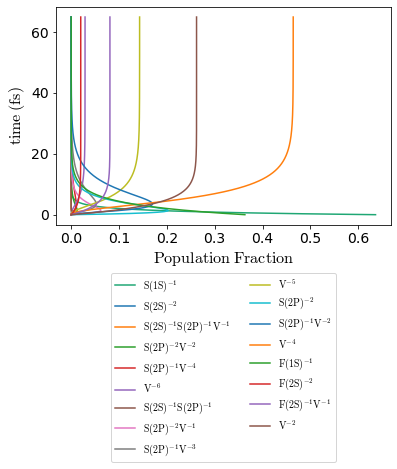

In [26]:
plt.figure()
plt.plot(Pop_1_1 + Pop_2_1 + Pop_3_1, time_steps, label = '$\mathrm{S(1S)^{-1}}$', color = sns.xkcd_rgb["jade"])
plt.plot(Pop_1_2, time_steps, label = '$\mathrm{S(2S)^{-2}}$')
plt.plot(Pop_1_3, time_steps, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}V^{-1}}$')
plt.plot(Pop_1_4, time_steps, label = '$\mathrm{S(2P)^{-2}V^{-2}}$')
plt.plot(Pop_1_5, time_steps, label = '$\mathrm{S(2P)^{-1}V^{-4}}$')
plt.plot(Pop_1_6, time_steps, label = '$\mathrm{V^{-6}}$')
plt.plot(Pop_2_2, time_steps, label = '$\mathrm{S(2S)^{-1}S(2P)^{-1}}$')
plt.plot(Pop_2_3, time_steps, label = '$\mathrm{S(2P)^{-2}V^{-1}}$')
plt.plot(Pop_2_4, time_steps, label = '$\mathrm{S(2P)^{-1}V^{-3}}$')
plt.plot(Pop_2_5, time_steps, label = '$\mathrm{V^{-5}}$')
plt.plot(Pop_3_2, time_steps, label = '$\mathrm{S(2P)^{-2}}$')
plt.plot(Pop_3_3, time_steps, label = '$\mathrm{S(2P)^{-1}V^{-2}}$')
plt.plot(Pop_3_4, time_steps, label = '$\mathrm{V^{-4}}$')
plt.plot(Pop_4_1 + Pop_5_1 + Pop_6_1, time_steps, label = '$\mathrm{F(1S)^{-1}}$')
plt.plot(Pop_4_2, time_steps, label = '$\mathrm{F(2S)^{-2}}$')
plt.plot(Pop_5_2, time_steps, label = '$\mathrm{F(2S)^{-1}V^{-1}}$')
plt.plot(Pop_6_2, time_steps, label = '$\mathrm{V^{-2}}$')
plt.ylabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.xlabel('$\mathrm{Population\;Fraction}$', fontsize = 16)
plt.legend(ncol = 2, bbox_to_anchor=(0.5,-0.2), loc='upper center')
plt.show()
#plt.savefig('All_Pathways.png', dpi = 150., bbox_inches = 'tight')

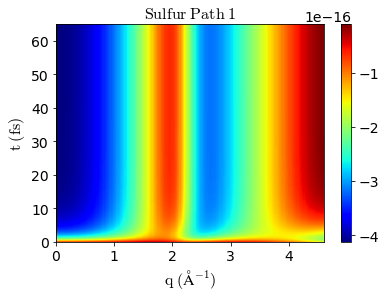

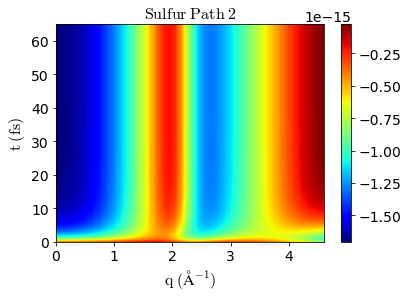

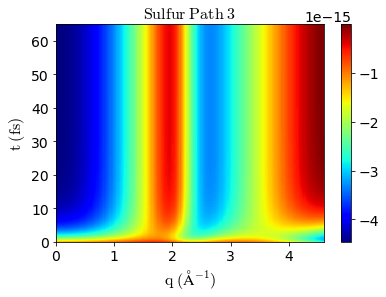

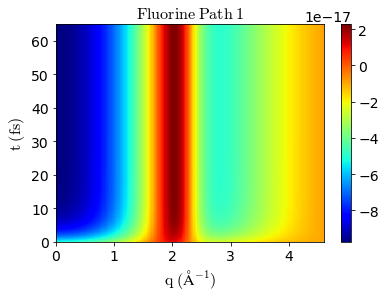

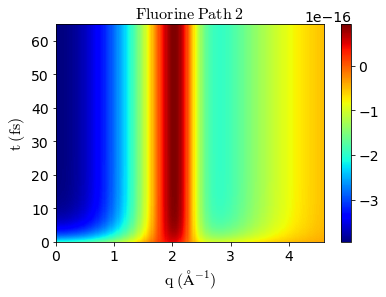

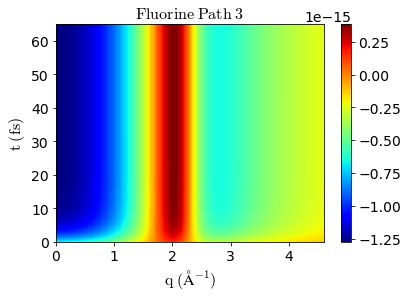

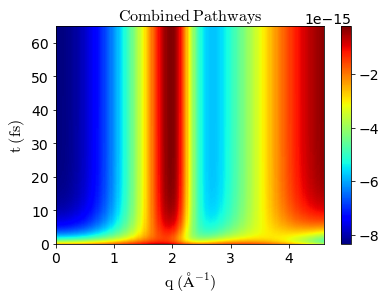

In [27]:
au2ang = 0.52918

Scatt_Ground = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-j0-total.dat')
Scatt_1_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s1-1s-j0-total.dat')
Scatt_1_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s2-2s-2s-j0-total.dat')
Scatt_1_3 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s3-2s-2p-4t1u-j0-total.dat')
Scatt_1_4 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s4-2p-2p-4t1u-j0-total.dat')
Scatt_1_5 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s5-2p-4t1u-1-j0-total.dat')
Scatt_1_6 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s6-4t1u-j0-total.dat')
Scatt_2_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s1-1s-j0-total.dat')
Scatt_2_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s2-2s-2p-1-j0-total.dat')
Scatt_2_3 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s3-2p-2p-4t1u-j0-total.dat')
Scatt_2_4 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s4-2p-4t1u-1-j0-total.dat')
Scatt_2_5 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s5-4t1u-j0-total.dat')
Scatt_3_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s1-1s-j0-total.dat')
Scatt_3_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s2-2p-2p-d-j0-total.dat')
Scatt_3_3 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s3-4t1u-1-j0-total.dat')
Scatt_3_4 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-s4-4t1u-1-j0-total.dat')
Scatt_4_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-f1-1s-j0-total.dat')
Scatt_4_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-f2-2-2s-j0-total.dat')
Scatt_5_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-f1-1s-j0-total.dat')
Scatt_5_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-f2-2s-2p-1t2u-2-j0-total.dat')
Scatt_6_1 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-f1-1s-j0-total.dat')
Scatt_6_2 = np.loadtxt('Theory_Data/Scattering_Patterns/sf6-f2-2-2p-1t2u-1-j0-total.dat')

Scatt_GroundI = Scatt_Ground[:,1] + 70.

Scatt_1_1Ie = Scatt_1_1[:,1] + 70.
Scatt_1_2Ie = Scatt_1_2[:,1] + 69.
Scatt_1_3Ie = Scatt_1_3[:,1] + 68.
Scatt_1_4Ie = Scatt_1_4[:,1] + 67.
Scatt_1_5Ie = Scatt_1_5[:,1] + 66.
Scatt_1_6Ie = Scatt_1_6[:,1] + 65.

Scatt_2_1Ie = Scatt_2_1[:,1] + 70.
Scatt_2_2Ie = Scatt_2_2[:,1] + 69.
Scatt_2_3Ie = Scatt_2_3[:,1] + 68.
Scatt_2_4Ie = Scatt_2_4[:,1] + 67.
Scatt_2_5Ie = Scatt_2_5[:,1] + 66.

Scatt_3_1Ie = Scatt_3_1[:,1] + 70.
Scatt_3_2Ie = Scatt_3_2[:,1] + 69.
Scatt_3_3Ie = Scatt_3_3[:,1] + 68.
Scatt_3_4Ie = Scatt_3_4[:,1] + 67.

Scatt_4_1Ie = Scatt_4_1[:,1] + 70.
Scatt_4_2Ie = Scatt_4_2[:,1] + 69.

Scatt_5_1Ie = Scatt_5_1[:,1] + 70.
Scatt_5_2Ie = Scatt_5_2[:,1] + 69.

Scatt_6_1Ie = Scatt_6_1[:,1] + 70.
Scatt_6_2Ie = Scatt_6_2[:,1] + 69.

Scatt_q = Scatt_Ground[:,0]/au2ang

PerDiff1_1e = (Scatt_1_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff1_2e = (Scatt_1_2Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff1_3e = (Scatt_1_3Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff1_4e = (Scatt_1_4Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff1_5e = (Scatt_1_5Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff1_6e = (Scatt_1_6Ie - Scatt_GroundI)/Scatt_GroundI

PerDiff2_1e = (Scatt_2_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff2_2e = (Scatt_2_2Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff2_3e = (Scatt_2_3Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff2_4e = (Scatt_2_4Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff2_5e = (Scatt_2_5Ie - Scatt_GroundI)/Scatt_GroundI

PerDiff3_1e = (Scatt_3_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff3_2e = (Scatt_3_2Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff3_3e = (Scatt_3_3Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff3_4e = (Scatt_3_4Ie - Scatt_GroundI)/Scatt_GroundI

PerDiff4_1e = (Scatt_4_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff4_2e = (Scatt_4_2Ie - Scatt_GroundI)/Scatt_GroundI

PerDiff5_1e = (Scatt_5_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff5_2e = (Scatt_5_2Ie - Scatt_GroundI)/Scatt_GroundI

PerDiff6_1e = (Scatt_6_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff6_2e = (Scatt_6_2Ie - Scatt_GroundI)/Scatt_GroundI

contour_array_1e = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array_1e[i,:] = Population_Array_1[0,i]*PerDiff1_1e + Population_Array_1[1,i]*PerDiff1_2e + Population_Array_1[2,i]*PerDiff1_3e + Population_Array_1[3,i]*PerDiff1_4e + Population_Array_1[4,i]*PerDiff1_5e + Population_Array_1[5,i]*PerDiff1_6e 

contour_array_2e = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array_2e[i,:] = Population_Array_2[0,i]*PerDiff2_1e + Population_Array_2[1,i]*PerDiff2_2e + Population_Array_2[2,i]*PerDiff2_3e + Population_Array_2[3,i]*PerDiff2_4e + Population_Array_2[4,i]*PerDiff2_5e

contour_array_3e = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array_3e[i,:] = Population_Array_3[0,i]*PerDiff3_1e + Population_Array_3[1,i]*PerDiff3_2e + Population_Array_3[2,i]*PerDiff3_3e + Population_Array_3[3,i]*PerDiff3_4e
    
contour_array_4e = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array_4e[i,:] = Population_Array_4[0,i]*PerDiff4_1e + Population_Array_4[1,i]*PerDiff4_2e
    
contour_array_5e = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array_5e[i,:] = Population_Array_5[0,i]*PerDiff5_1e + Population_Array_5[1,i]*PerDiff5_2e
    
contour_array_6e = np.zeros((time_steps.size, Scatt_q.size))
for i in range(0, time_steps.size):
    contour_array_6e[i,:] = Population_Array_6[0,i]*PerDiff6_1e + Population_Array_6[1,i]*PerDiff6_2e
    
qhigh = 230

plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array_1e[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Sulfur\;Path\;1}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('sulfur_1.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array_2e[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Sulfur\;Path\;2}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('sulfur_2.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array_3e[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Sulfur\;Path\;3}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('sulfur_3.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array_4e[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Fluorine\;Path\;1}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('fluorine_1.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array_5e[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Fluorine\;Path\;2}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('fluorine_2.png', dpi = 150., bbox_inches = 'tight')

plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*contour_array_6e[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Fluorine\;Path\;3}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('fluorine_3.png', dpi = 150., bbox_inches = 'tight')

Total_Contoure = contour_array_1e + contour_array_2e + contour_array_3e + contour_array_4e + contour_array_5e + contour_array_6e
plt.figure()
plt.pcolormesh(Scatt_q[0:qhigh], time_steps, Comparison_Factor*C*Total_Contoure[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Combined\;Pathways}$', fontsize = 16)
plt.colorbar()
plt.show()
#plt.savefig('6_Pathways_withe.png', dpi = 150., bbox_inches = 'tight')


## Plotting total result with the colorbar underneath, for figure 4

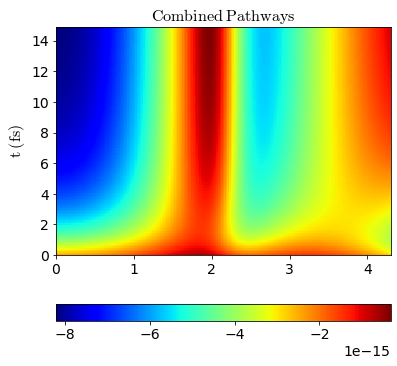

In [28]:
Total_Contoure = contour_array_1e + contour_array_2e + contour_array_3e + contour_array_4e + contour_array_5e + contour_array_6e
plt.figure(figsize = (6,6))
plt.pcolormesh(Scatt_q[0:qhigh], time_steps[0:150], Comparison_Factor*C*Total_Contoure[0:150,0:qhigh], cmap = 'jet')
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.title('$\mathrm{Combined\;Pathways}$', fontsize = 16)
plt.colorbar(orientation = 'horizontal', ticks = [-8e-15, -6e-15, -4e-15, -2e-15, 0e-15])
plt.xlim(0, 4.3)
plt.show()
#plt.savefig('6_Pathways_withe.png', dpi = 150., bbox_inches = 'tight')

## From the combined pathway depicted above, we predict how the nonlinear fitting coefficient should change with time.

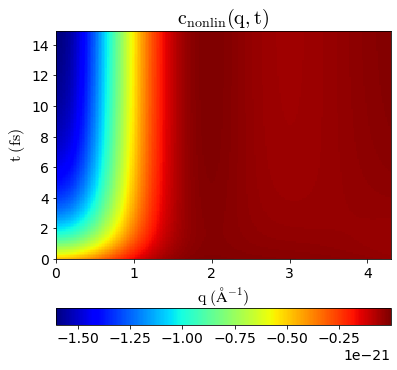

In [29]:
Contour_Subset = Total_Contoure[0:150, :]

for i in range(0, 150):
    Contour_Subset[i,:] = Total_Contoure[i,:]*(Theory_Scale*Density_Median*l_cell/Match_Scale)*Scatt_GroundI*Comparison_Factor*C
    
Total_Contoure = contour_array_1e + contour_array_2e + contour_array_3e + contour_array_4e + contour_array_5e + contour_array_6e
plt.figure(figsize = (6,6))
plt.pcolormesh(Scatt_q[0:qhigh], time_steps[0:150], Contour_Subset[:,0:qhigh], cmap = 'jet')
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 16)
plt.ylabel('$\mathrm{t\;(fs)}$', fontsize = 16)
plt.colorbar(orientation = 'horizontal')
plt.xlim(0, 4.3)
plt.title('$\mathrm{c_{nonlin}(q,t)}$', fontsize = 20)
plt.show()
#plt.savefig('c_dynamics.png', dpi = 150., bbox_inches = 'tight')

## To save alpha(q,t) array for Matlab plotting, uncomment the line.

In [30]:
from scipy.io import savemat

#savemat('Total_Contour_with_e.mat',{'q':Scatt_q,'t':time_steps,'Contour':Total_Contoure})

## Making panels C and D of Figure 4

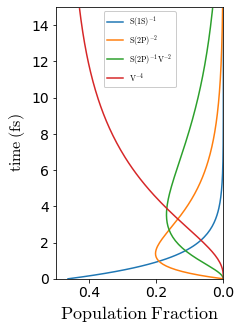

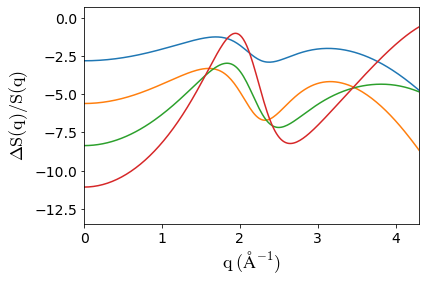

In [31]:
#plt.figure(figsize = (9, 15)) #For High Res Legend
plt.figure(figsize = (3,5))
plt.plot(Pop_3_1[0:150], time_steps[0:150], label = '$\mathrm{S(1S)^{-1}}$')
plt.plot(Pop_3_2[0:150], time_steps[0:150], label = '$\mathrm{S(2P)^{-2}}$')
plt.plot(Pop_3_3[0:150], time_steps[0:150], label = '$\mathrm{S(2P)^{-1}V^{-2}}$')
plt.plot(Pop_3_4[0:150], time_steps[0:150], label = '$\mathrm{V^{-4}}$')
plt.ylabel('$\mathrm{time\;(fs)}$', fontsize = 16)
plt.xlabel('$\mathrm{Population\;Fraction}$', fontsize = 18)
#plt.legend( prop={'size': 24}, framealpha = 1.0) #For High Res Legend
plt.legend( prop={'size': 8}, framealpha = 1.0)
plt.ylim(0, 15)
plt.yticks(np.arange(0, 15, 2))
plt.xlim(0.5,0)
plt.show()
#plt.savefig('Sulfur_3_Legend.png', dpi = 150., bbox_inches = 'tight')


Scatt_q = Scatt_Ground[:,0]/au2ang
PerDiff3_1e = 100*(Scatt_3_1Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff3_2e = 100*(Scatt_3_2Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff3_3e = 100*(Scatt_3_3Ie - Scatt_GroundI)/Scatt_GroundI
PerDiff3_4e = 100*(Scatt_3_4Ie - Scatt_GroundI)/Scatt_GroundI

plt.figure()
plt.plot(Scatt_q, PerDiff3_1e)
plt.plot(Scatt_q, PerDiff3_2e)
plt.plot(Scatt_q, PerDiff3_3e)
plt.plot(Scatt_q, PerDiff3_4e)
plt.xlabel('$\mathrm{q\;(\AA^{-1})}$', fontsize = 18)
plt.ylabel('$\mathrm{\Delta S(q)/S(q)}$', fontsize = 18)
plt.xlim(0, 4.3)
plt.show()
#plt.savefig('Sulfur_3_Scatt.png', dpi = 150., bbox_inches = 'tight')
